# **EV Adoption Rate Based On Customer Preferences 🔋📈**

<h2 style="color:#38761D;"><b>Description</b></h2>

The global automotive industry is undergoing a massive shift towards **Electric Vehicles (EVs)**. However, despite government subsidies and environmental concerns, many potential buyers hesitate due to "Range Anxiety"—the fear that a vehicle has insufficient range to reach its destination and would strand the vehicle's occupants.

This dataset is a comprehensive, synthetic snapshot of **10,000 potential car buyers**. It is designed analyze the demographic, geographic, and psychological factors that influence EV adoption and range anxiety

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("EV_Adoption_and_Range_Anxiety_Dataset.csv")

<h3 style="color:#38761D;"><b>Initial inspection</b></h3>


In [3]:
df.head()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


In [4]:
df.shape

(10000, 15)

In [5]:
df.tail()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No
9999,EV10000,64,Other,59052.0,Suburban,24.0,2,Hatchback,1,9,Yes,5.0,Yes,Low,No


In [6]:
df.columns

Index(['Buyer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'City_Type',
       'Daily_Commute_km', 'Number_of_Cars_Owned', 'Current_Car_Type',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Home_Charging_Possible', 'Environmental_Concern_Level',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

In [7]:
df.columns=(df.columns
             .str.strip()
             .str.lower()
            )
df.columns
            

Index(['buyer_id', 'age', 'gender', 'annual_income_usd', 'city_type',
       'daily_commute_km', 'number_of_cars_owned', 'current_car_type',
       'charging_stations_near_home', 'charging_stations_near_work',
       'home_charging_possible', 'environmental_concern_level',
       'subsidy_available', 'range_anxiety_level', 'will_buy_ev'],
      dtype='object')

<h3 style="color:#38761D;"><b> Dataset Info</b></h3>

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   buyer_id                     10000 non-null  object 
 1   age                          10000 non-null  int64  
 2   gender                       10000 non-null  object 
 3   annual_income_usd            9822 non-null   float64
 4   city_type                    10000 non-null  object 
 5   daily_commute_km             9819 non-null   float64
 6   number_of_cars_owned         10000 non-null  int64  
 7   current_car_type             10000 non-null  object 
 8   charging_stations_near_home  10000 non-null  int64  
 9   charging_stations_near_work  10000 non-null  int64  
 10  home_charging_possible       10000 non-null  object 
 11  environmental_concern_level  9816 non-null   float64
 12  subsidy_available            10000 non-null  object 
 13  range_anxiety_lev

In [9]:
df.dtypes

buyer_id                        object
age                              int64
gender                          object
annual_income_usd              float64
city_type                       object
daily_commute_km               float64
number_of_cars_owned             int64
current_car_type                object
charging_stations_near_home      int64
charging_stations_near_work      int64
home_charging_possible          object
environmental_concern_level    float64
subsidy_available               object
range_anxiety_level             object
will_buy_ev                     object
dtype: object

In [10]:
df.describe(include='all')

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev
count,10000,10000.000000,10000,9822.000000,10000,9819.000000,10000.000000,10000,10000.000000,10000.000000,10000,9816.000000,10000,10000,10000
unique,10000,NaN,3,NaN,3,NaN,NaN,4,NaN,NaN,2,NaN,2,3,2
top,EV00001,NaN,Male,NaN,Urban,NaN,NaN,Sedan,NaN,NaN,Yes,NaN,Yes,Low,No
freq,1,NaN,5201,NaN,4941,NaN,NaN,4000,NaN,NaN,6163,NaN,6008,8310,8250
mean,NaN,46.936200,NaN,85378.485848,NaN,41.105418,1.859900,NaN,5.346900,7.458200,NaN,2.982783,NaN,NaN,NaN
std,NaN,12.945968,NaN,32838.684167,NaN,23.351276,0.855421,NaN,4.049074,5.259374,NaN,1.413784,NaN,NaN,NaN
min,NaN,25.000000,NaN,30000.000000,NaN,5.000000,1.000000,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,36.000000,NaN,61369.500000,NaN,23.250000,1.000000,NaN,2.000000,3.000000,NaN,2.000000,NaN,NaN,NaN
50%,NaN,47.000000,NaN,84708.000000,NaN,40.200000,2.000000,NaN,5.000000,6.000000,NaN,3.000000,NaN,NaN,NaN
75%,NaN,58.000000,NaN,107383.250000,NaN,57.000000,2.000000,NaN,8.000000,11.000000,NaN,4.000000,NaN,NaN,NaN


<h3 style="color:#38761D;"><b> Checking For Null Values</b></h3>

In [11]:
df.isnull().sum()

buyer_id                         0
age                              0
gender                           0
annual_income_usd              178
city_type                        0
daily_commute_km               181
number_of_cars_owned             0
current_car_type                 0
charging_stations_near_home      0
charging_stations_near_work      0
home_charging_possible           0
environmental_concern_level    184
subsidy_available                0
range_anxiety_level              0
will_buy_ev                      0
dtype: int64

In [12]:
for column in df.columns:
        print(column)
        print(df[column].unique())
        print("-" * 40)

buyer_id
['EV00001' 'EV00002' 'EV00003' ... 'EV09998' 'EV09999' 'EV10000']
----------------------------------------
age
[56 36 42 31 48 34 38 65 29 53 25 30 37 54 44 33 59 69 35 68 66 61 60 32
 64 63 43 40 67 58 49 55 45 52 47 51 62 27 28 39 46 50 26 41 57]
----------------------------------------
gender
['Male' 'Female' 'Other']
----------------------------------------
annual_income_usd
[ 44906.  88754. 155958. ...  97743. 103628.  59052.]
----------------------------------------
city_type
['Rural' 'Urban' 'Suburban']
----------------------------------------
daily_commute_km
[ 18.1   5.   32.2  89.9  71.   75.7  85.4  12.   40.6  42.9  45.   49.5
  44.7  30.6  35.4  22.9  26.9  49.1  52.1  67.6  85.2  95.   40.   81.3
  21.8  27.   18.3  56.   22.4  50.7  42.3  16.7  58.5  21.7  33.1  37.1
  45.1  22.   64.7   8.3  11.9  19.4  60.5  45.8  59.2  38.9  42.1  46.7
  24.4  35.3  50.1  78.9  81.1  32.9  58.9  49.3   nan  51.8  49.4  71.4
  29.2  44.3  52.2  69.6  13.   15.2  50.9  26.4  74

<h3 style="color:#38761D;"><b> Checking For Outliers</b></h3>

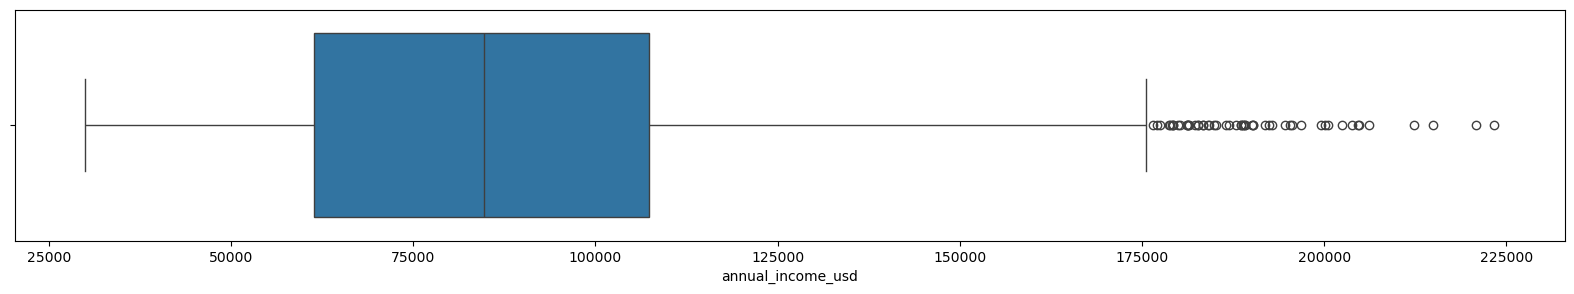

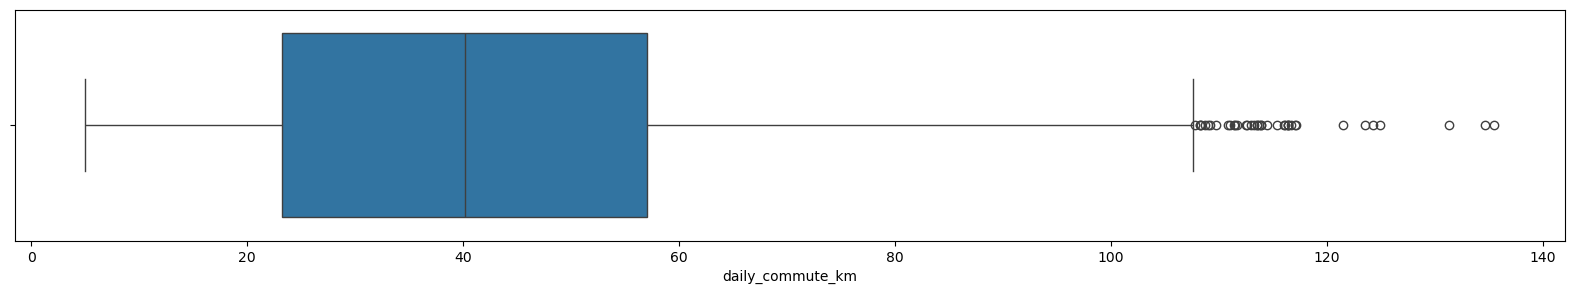

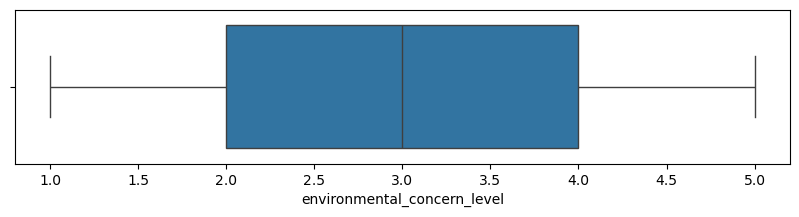

In [13]:

plt.figure(figsize=(20,3))
sns.boxplot(x=df["annual_income_usd"])
plt.show()

plt.figure(figsize=(20,3))
sns.boxplot(x=df["daily_commute_km"])
plt.show()

plt.figure(figsize=(10,2))
sns.boxplot(x=df["environmental_concern_level"])
plt.show()

<h3 style="color:#38761D;"><b> Filling missing values using mean</b></h3>

In [14]:

df["annual_income_usd"] = df["annual_income_usd"].fillna(df["annual_income_usd"].median())
df["daily_commute_km"] = df["daily_commute_km"].fillna(df["daily_commute_km"].median())
df["environmental_concern_level"] = df["environmental_concern_level"].fillna(df["environmental_concern_level"].mean())

<h3 style="color:#38761D;"><b> Checking For Duplicates</b></h3>

In [15]:

df.isnull().sum()

buyer_id                       0
age                            0
gender                         0
annual_income_usd              0
city_type                      0
daily_commute_km               0
number_of_cars_owned           0
current_car_type               0
charging_stations_near_home    0
charging_stations_near_work    0
home_charging_possible         0
environmental_concern_level    0
subsidy_available              0
range_anxiety_level            0
will_buy_ev                    0
dtype: int64

<h3 style="color:#38761D;"><b> Final Check</b></h3>

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.head()

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


In [18]:
df.isnull().sum()

buyer_id                       0
age                            0
gender                         0
annual_income_usd              0
city_type                      0
daily_commute_km               0
number_of_cars_owned           0
current_car_type               0
charging_stations_near_home    0
charging_stations_near_work    0
home_charging_possible         0
environmental_concern_level    0
subsidy_available              0
range_anxiety_level            0
will_buy_ev                    0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.dtypes

buyer_id                        object
age                              int64
gender                          object
annual_income_usd              float64
city_type                       object
daily_commute_km               float64
number_of_cars_owned             int64
current_car_type                object
charging_stations_near_home      int64
charging_stations_near_work      int64
home_charging_possible          object
environmental_concern_level    float64
subsidy_available               object
range_anxiety_level             object
will_buy_ev                     object
dtype: object

In [21]:
df.shape

(10000, 15)

## **Analysisng the categorical data**

*Finding the unique values of Categorical columns*

In [22]:
print("city_type:", df["city_type"].unique())
print("current_car_type:", df["current_car_type"].unique())
print("range_anxiety_level:", df["range_anxiety_level"].unique())
print("gender:", df["gender"].unique())

city_type: ['Rural' 'Urban' 'Suburban']
current_car_type: ['Truck' 'SUV' 'Sedan' 'Hatchback']
range_anxiety_level: ['Low' 'Medium' 'High']
gender: ['Male' 'Female' 'Other']


In [23]:
#Finding the no of  unique values of categorical columns

print("city_type:", df["city_type"].nunique())
print("current_car_type:", df["current_car_type"].nunique())
print("range_anxiety_level:", df["range_anxiety_level"].nunique())


city_type: 3
current_car_type: 4
range_anxiety_level: 3


In [24]:
#Finding how muchtimes  unique values of categorical columns repeates
print("\ncity_type Distribution:\n", df["city_type"].value_counts())

print("\ncurrent_car_type Distribution\n", df["current_car_type"].value_counts())

print("\nrange_anxiety_level Distribution:\n", df["range_anxiety_level"].value_counts())

print("\nGender Distribution Distribution:\n", df["gender"].value_counts())

print("\nwill_buy_ev Distribution:\n",df["will_buy_ev"].value_counts())


city_type Distribution:
 city_type
Urban       4941
Suburban    3563
Rural       1496
Name: count, dtype: int64

current_car_type Distribution
 current_car_type
Sedan        4000
SUV          3486
Hatchback    1523
Truck         991
Name: count, dtype: int64

range_anxiety_level Distribution:
 range_anxiety_level
Low       8310
Medium    1523
High       167
Name: count, dtype: int64

Gender Distribution Distribution:
 gender
Male      5201
Female    4498
Other      301
Name: count, dtype: int64

will_buy_ev Distribution:
 will_buy_ev
No     8250
Yes    1750
Name: count, dtype: int64


In [25]:
#Finding percentage of categorical columns
print(df["will_buy_ev"].value_counts(normalize=True) * 100)
print("\n",df["city_type"].value_counts(normalize=True) * 100)
print("\n",df["range_anxiety_level"].value_counts(normalize=True) * 100)
print("\n",df["current_car_type"].value_counts(normalize=True) * 100)
print("\n",df["gender"].value_counts(normalize=True) * 100)


will_buy_ev
No     82.5
Yes    17.5
Name: proportion, dtype: float64

 city_type
Urban       49.41
Suburban    35.63
Rural       14.96
Name: proportion, dtype: float64

 range_anxiety_level
Low       83.10
Medium    15.23
High       1.67
Name: proportion, dtype: float64

 current_car_type
Sedan        40.00
SUV          34.86
Hatchback    15.23
Truck         9.91
Name: proportion, dtype: float64

 gender
Male      52.01
Female    44.98
Other      3.01
Name: proportion, dtype: float64


In [26]:
df.columns

Index(['buyer_id', 'age', 'gender', 'annual_income_usd', 'city_type',
       'daily_commute_km', 'number_of_cars_owned', 'current_car_type',
       'charging_stations_near_home', 'charging_stations_near_work',
       'home_charging_possible', 'environmental_concern_level',
       'subsidy_available', 'range_anxiety_level', 'will_buy_ev'],
      dtype='object')

 ## **Stastical Analysis**

In [27]:
numerical_cols = [
    "age",
    "annual_income_usd",
    "daily_commute_km",
    "number_of_cars_owned",
    "charging_stations_near_home",
    "charging_stations_near_work",
    "environmental_concern_level",
]
print("\nstastical analsis of the numerical columns\n",df[numerical_cols].agg(["min", "max", "mean","median", "std"]).T.round(2))



stastical analsis of the numerical columns
                                  min       max      mean   median       std
age                             25.0      69.0     46.94     47.0     12.95
annual_income_usd            30000.0  223345.0  85366.55  84708.0  32545.20
daily_commute_km                 5.0     135.5     41.09     40.2     23.14
number_of_cars_owned             1.0       4.0      1.86      2.0      0.86
charging_stations_near_home      0.0      14.0      5.35      5.0      4.05
charging_stations_near_work      0.0      19.0      7.46      6.0      5.26
environmental_concern_level      1.0       5.0      2.98      3.0      1.40


In [28]:
df.head()

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


## **Summarizing the Data using EDA**

In [30]:
#EV purchase intention data based on range anxiety
print("EV purchase intention data based on range anxiety\n",
      df.groupby("range_anxiety_level")["will_buy_ev"].value_counts())

EV purchase intention data based on range anxiety
 range_anxiety_level  will_buy_ev
High                 No              166
                     Yes               1
Low                  No             6659
                     Yes            1651
Medium               No             1425
                     Yes              98
Name: count, dtype: int64


In [31]:
#EV purchase percentage based on range anxiety
print("EV purchase percentage based on range anxiety\n",
      df.groupby("range_anxiety_level")["will_buy_ev"]
      .apply(lambda x: (x == "Yes").mean() * 100).round(2))

EV purchase percentage based on range anxiety
 range_anxiety_level
High       0.60
Low       19.87
Medium     6.43
Name: will_buy_ev, dtype: float64


In [32]:
#EV purchase percentage based on subsidy availability
print("EV purchase percentage based on subsidy availability\n",
      df.groupby("subsidy_available")["will_buy_ev"]
      .apply(lambda x: (x == "Yes").mean() * 100).round(2))

EV purchase percentage based on subsidy availability
 subsidy_available
No      2.53
Yes    27.45
Name: will_buy_ev, dtype: float64


In [101]:
#EV purchase intention based on subsidy availability
print("EV purchase intention based on subsidy availability\n",
      df.groupby("subsidy_available")["will_buy_ev"].value_counts())
    

EV purchase intention based on subsidy availability
 subsidy_available  will_buy_ev
No                 No             3891
                   Yes             101
Yes                No             4359
                   Yes            1649
Name: count, dtype: int64


In [102]:
# Average of  environmental concern influencing EV purchase intention
print(" How  Average environmental concern influencing EV purchase intention\n",
      df.groupby("will_buy_ev")["environmental_concern_level"].mean().round(2))

 How  Average environmental concern influencing EV purchase intention
 will_buy_ev
No     2.75
Yes    4.09
Name: environmental_concern_level, dtype: float64


In [103]:
#How  environmental concern affecting no of people's EV purchase intention
print("How  environmental concern affecting no of people's EV purchase intention\n",
      df.groupby("environmental_concern_level")["will_buy_ev"].value_counts())

How  environmental concern affecting no of people's EV purchase intention
 environmental_concern_level  will_buy_ev
1.000000                     No             1970
                             Yes              43
2.000000                     No             1852
                             Yes              96
2.982783                     No              149
                             Yes              35
3.000000                     No             1675
                             Yes             283
4.000000                     No             1486
                             Yes             503
5.000000                     No             1118
                             Yes             790
Name: count, dtype: int64


In [42]:
df.head()

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,range_anxiety_score,will_buy_ev score
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No,1,5
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No,1,5
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes,2,3
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No,1,4
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No,1,5


In [120]:
#Average of daily commute and its influence on range anxiety level
print(" Average of daily commute and its influence on range anxiety level\n",
      df.groupby("range_anxiety_level")["daily_commute_km"].mean().round(2))

 Average of daily commute and its influence on range anxiety level
 range_anxiety_level
High      60.15
Low       39.36
Medium    48.44
Name: daily_commute_km, dtype: float64


In [121]:
print("max income:",df["annual_income_usd"].max())
print("mininome:",df["annual_income_usd"].min())

print("\nData showing how Average income is influencing EV purchase intention\n",
      df.groupby("will_buy_ev")["annual_income_usd"].mean().round(2))

max income: 223345.0
mininome: 30000.0

Data showing how Average income is influencing EV purchase intention
 will_buy_ev
No     82769.04
Yes    97611.94
Name: annual_income_usd, dtype: float64


In [122]:
#EV purchase intention based on current car type
print("EV purchase intention based on current car type\n",
      df.groupby("current_car_type")["will_buy_ev"].value_counts())

EV purchase intention based on current car type
 current_car_type  will_buy_ev
Hatchback         No             1257
                  Yes             266
SUV               No             2855
                  Yes             631
Sedan             No             3311
                  Yes             689
Truck             No              827
                  Yes             164
Name: count, dtype: int64


In [123]:
#EV purchase intention percentage based on current car type
print("EV purchase intention percentage based on current car type\n",
      df.groupby("current_car_type")["will_buy_ev"]
.apply(lambda x: (x == "Yes").mean() * 100).round(2))

EV purchase intention percentage based on current car type
 current_car_type
Hatchback    17.47
SUV          18.10
Sedan        17.22
Truck        16.55
Name: will_buy_ev, dtype: float64


In [124]:
#EV purchase percentage based on charging_stations_near_home
print("EV purchase percentage based on charging_stations_near_home\n",
      df.groupby("charging_stations_near_home")["will_buy_ev"]
      .apply(lambda x: (x == "Yes").mean() * 100).round(2))

EV purchase percentage based on charging_stations_near_home
 charging_stations_near_home
0     17.81
1     19.77
2     18.74
3     15.50
4     17.02
5     15.43
6     15.92
7     15.33
8     19.57
9     19.84
10    20.60
11    17.46
12    17.32
13    18.16
14    17.16
Name: will_buy_ev, dtype: float64


In [125]:
#EV purchase percentage based on charging_stations_near_work
print("EV purchase percentage based on charging_stations_near_work \n",
      df.groupby("charging_stations_near_work")["will_buy_ev"]
      .apply(lambda x: (x == "Yes").mean() * 100).round(2))

EV purchase percentage based on charging_stations_near_work 
 charging_stations_near_work
0     18.21
1     16.73
2     18.80
3     17.22
4     18.44
5     18.22
6     15.62
7     16.69
8     15.58
9     17.85
10    18.56
11    20.92
12    17.88
13    16.55
14    19.05
15    16.67
16    19.87
17    15.79
18    18.28
19    16.79
Name: will_buy_ev, dtype: float64


In [126]:
#EV purchase intention percentage based on home charging availability
print("EV purchase intention percentage based on home charging availability\n",
      df.groupby("home_charging_possible")["will_buy_ev"]
      .apply(lambda x: (x == "Yes").mean() * 100).round(2))

EV purchase intention percentage based on home charging availability
 home_charging_possible
No     13.37
Yes    20.07
Name: will_buy_ev, dtype: float64


In [127]:
#EV purchase intention count based on home charging availability
print("EV purchase intention count based on home charging availability\n",
      df.groupby("home_charging_possible")["will_buy_ev"].value_counts())

EV purchase intention count based on home charging availability
 home_charging_possible  will_buy_ev
No                      No             3324
                        Yes             513
Yes                     No             4926
                        Yes            1237
Name: count, dtype: int64


In [128]:
#How much home charging avalability(percentage) is in each city type 
print("How much home charging avalability(percentage) is in each city type \n",
      df.groupby("city_type")["home_charging_possible"]
.apply(lambda x: (x == "Yes").mean() * 100).round(2))

How much home charging avalability(percentage) is in each city type 
 city_type
Rural       90.84
Suburban    79.68
Urban       39.77
Name: home_charging_possible, dtype: float64


In [129]:
#EV purchase intention based on city type
print("EV purchase intention based on city type\n",
      df.groupby("city_type")["will_buy_ev"]
.apply(lambda x: (x == "Yes").mean() * 100).round(2))

EV purchase intention based on city type
 city_type
Rural       18.98
Suburban    17.68
Urban       16.92
Name: will_buy_ev, dtype: float64


In [130]:
#EV purchase intention based on gender
print("EV purchase intention based on gender\n",
      df.groupby("gender")["will_buy_ev"].value_counts())

EV purchase intention based on gender
 gender  will_buy_ev
Female  No             3687
        Yes             811
Male    No             4312
        Yes             889
Other   No              251
        Yes              50
Name: count, dtype: int64


In [131]:
#does age have  influence on  buying EV vehicles
print("EV purchase intention based on age\n",
      df.groupby("age")["will_buy_ev"].value_counts())

EV purchase intention based on age
 age  will_buy_ev
25   No             188
     Yes             28
26   No             176
     Yes             44
27   No             182
                   ... 
67   Yes             36
68   No             184
     Yes             31
69   No             174
     Yes             42
Name: count, Length: 90, dtype: int64


In [132]:
print("Average age of people showing intention inEV purchase\n",
      df.groupby("will_buy_ev")["age"].mean().round(2))

Average age of people showing intention inEV purchase
 will_buy_ev
No     46.91
Yes    47.06
Name: age, dtype: float64


In [133]:
#Checking the releation btwn Average daily commute , city_type,home_charging_availability and Ev purchase intention
print("Releation btwn Average daily commute , city_type,home_charging_availability and Ev purchase intention\n",
      df.groupby(["city_type", "home_charging_possible","will_buy_ev"])
      ["daily_commute_km"].mean().round(2))

Releation btwn Average daily commute , city_type,home_charging_availability and Ev purchase intention
 city_type  home_charging_possible  will_buy_ev
Rural      No                      No             46.17
                                   Yes            28.57
           Yes                     No             40.59
                                   Yes            38.33
Suburban   No                      No             40.03
                                   Yes            38.66
           Yes                     No             41.27
                                   Yes            41.71
Urban      No                      No             42.04
                                   Yes            38.04
           Yes                     No             41.14
                                   Yes            40.21
Name: daily_commute_km, dtype: float64


## **conclusions and interpretations  from summarizing the data and statisical Analysis**
1. Range anxiety negatively influence the chances of people choosing Ev vehicles, people travelling more than average of 60 km has high range     anxiety.
2. Subsidy availability drastically increses the chances of  people choosing Ev vehicles 
3. min annual income :30000.0
4. max annual income: 223345.0
5. people having average annual income close to 100K dollars shows more intrest in buying Ev vehicles
6. current car types doesnt have any strong infulence on the matter of chosing Ev vehicles 
7. charging stations near home and work is not creating any big influence in choosing Ev cars as per data
8. But homecharging availability has strong influence on pushing people in buying Ev vehicles
9. In percentage wise people living on Rural areas are showing more intrest in buying Ev vehicles, one reason is people in Rural areas more home charging availabilty.
10. gender aand age doesn't showsany diff in intention of selecting Ev vehicles

## **Business Recommendation:**
1. people possesing  range anxiety a very low intrest , so by increasing the battery range ,establishing more charging stations and creating awareness regarding the good range offered by company can make difference
2. marketing vehicles in states allowing subsisadary foe buying ev can create more sales
3. Focusing more on rural areas can also increase the sales ,bcz people shows more intrest compared to urban and suburban areas


## **Data wrangling**

In [135]:
#Creating will_buy_ev_score for easily finding the chances of a person in selecting Ev vehicles 
df["will_buy_ev_score"]= (df["range_anxiety_level"].map({  "Low": 3,"Medium": 2,"High": 1})+
                          df["home_charging_possible"].map({ "Yes":1,"No":0})+
                          df["subsidy_available"].map({ "Yes":1,"No":0}))
                          

*people having more will_buy_ev_score showsmore intrest in buying Ev vehicles*

In [136]:
df.head()

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,will_buy_ev_score
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No,5
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No,5
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes,3
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No,4
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No,5


In [137]:
print("EV purchase intention  percentage based on will_buy_ev_score\n",
      df.groupby("will_buy_ev_score")["will_buy_ev"].value_counts())

EV purchase intention  percentage based on will_buy_ev_score
 will_buy_ev_score  will_buy_ev
1                  No               68
2                  No              679
                   Yes               2
3                  No             1660
                   Yes             123
4                  No             3343
                   Yes             462
5                  No             2500
                   Yes            1163
Name: count, dtype: int64


*with the increase in will_buy_ev_score no of people willing to select EEV also increasing*

In [138]:
#In percentage format
print("EV purchase intention percentage based on will_buy_ev_score\n",
      df.groupby("will_buy_ev_score")["will_buy_ev"]
      .apply(lambda x: (x == "Yes").mean() * 100).round(2))

EV purchase intention percentage based on will_buy_ev_score
 will_buy_ev_score
1     0.00
2     0.29
3     6.90
4    12.14
5    31.75
Name: will_buy_ev, dtype: float64


In [139]:
print("EV purchase intention percentage based on range anxiety\n",
      df.groupby("range_anxiety_level")["will_buy_ev_score"].mean().round(2))

EV purchase intention percentage based on range anxiety
 range_anxiety_level
High      1.59
Low       4.33
Medium    2.65
Name: will_buy_ev_score, dtype: float64


*Its clear that Range anxiety is the main factor which is preventing people from selecting EV vehicles*

## **Visualizations**

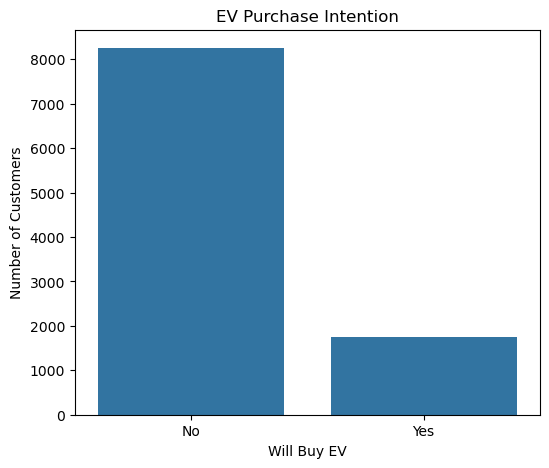

In [140]:
# Graph representing overall nuumber of customers and their intrest regarding Ev vehicle purchase
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="will_buy_ev")

plt.title("EV Purchase Intention")
plt.xlabel("Will Buy EV")
plt.ylabel("Number of Customers")

plt.show()


*1750 customers shows intrest where 8250 not*

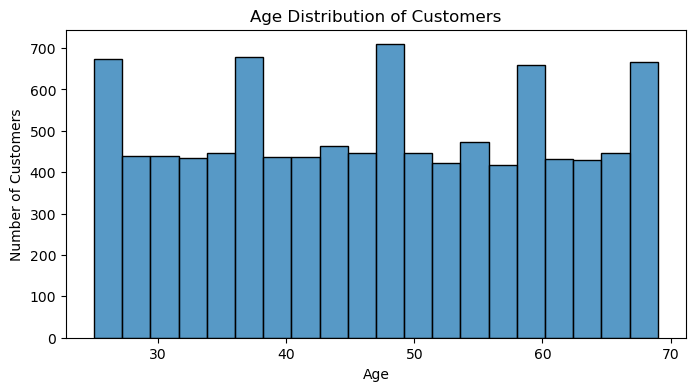

In [141]:
#Checking wheather the age distribution has influence on EV buying intention.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.histplot(data=df, x="age", bins=20)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

*Figures says age doesnt have a clear influence,both young and old shows similar pattern*

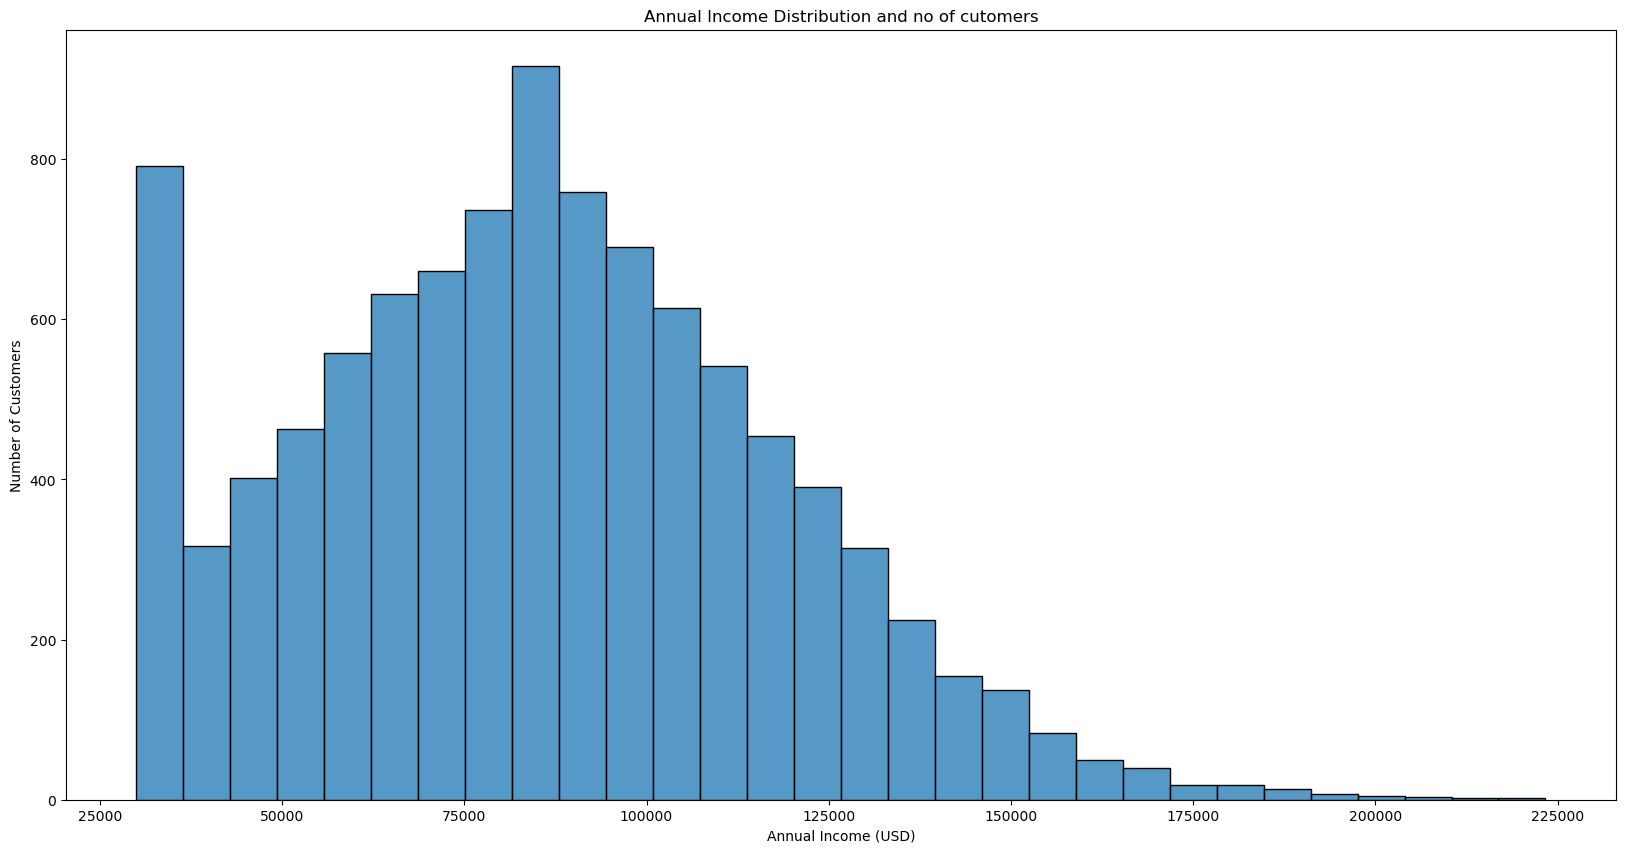

In [142]:
#checking wheather peoples annualincome plays a role in selecting ev
plt.figure(figsize=(20,10))

sns.histplot(data=df, x="annual_income_usd", bins=30)

plt.title("Annual Income Distribution and no of cutomers")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Number of Customers")

plt.show()

*From figure its clear that people having an annual income close to 100k dollars shows the most intrest*

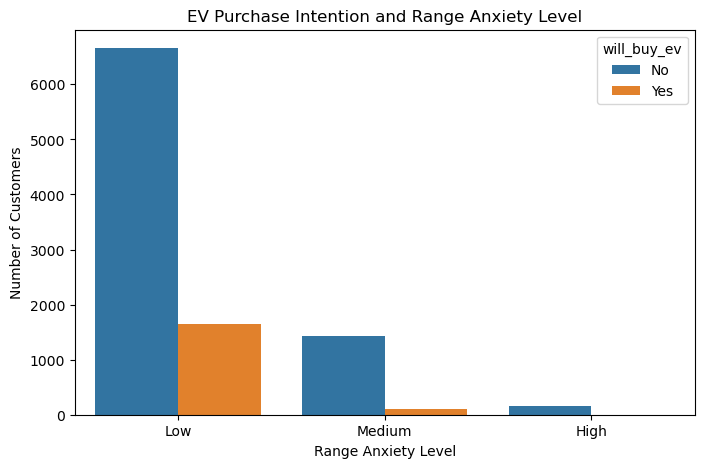

In [143]:
#Relation btwn ev purchase intention and Range Anxiety Level
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="range_anxiety_level",
    hue="will_buy_ev"
)

plt.title("EV Purchase Intention and Range Anxiety Level")
plt.xlabel("Range Anxiety Level")
plt.ylabel("Number of Customers")

plt.show()


*From graph its clear that anxiety regarging the battery charge creates a big influence*

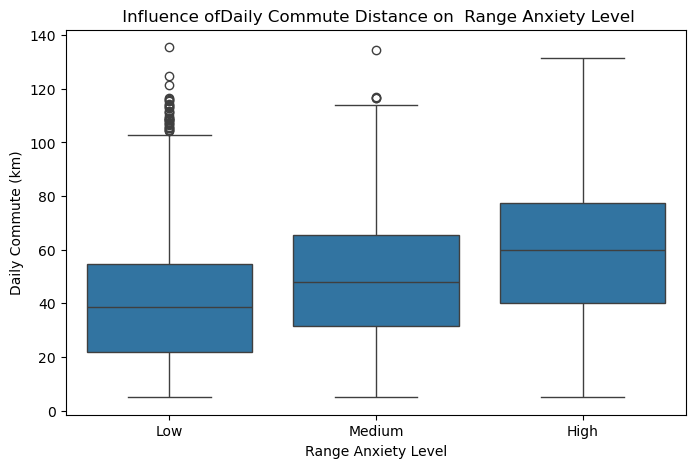

In [144]:
#Boxplot showing how daily commute distance influence range anxiety level
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="range_anxiety_level",
    y="daily_commute_km"
)

plt.title(" Influence ofDaily Commute Distance on  Range Anxiety Level")
plt.xlabel("Range Anxiety Level")
plt.ylabel("Daily Commute (km)")

plt.show()

*Range anxiety increases with increase in daily commute distance*

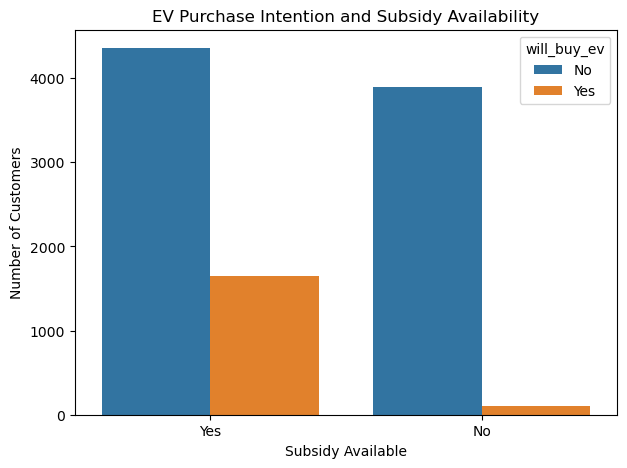

In [145]:
# how much is avalability of subsidy pushes people to select EV vehicles
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="subsidy_available",
    hue="will_buy_ev"
)

plt.title("EV Purchase Intention and Subsidy Availability")
plt.xlabel("Subsidy Available")
plt.ylabel("Number of Customers")

plt.show()

*Clearly subsidy availabilty pushes people in choosing EV vehicles over traditional vehicles*

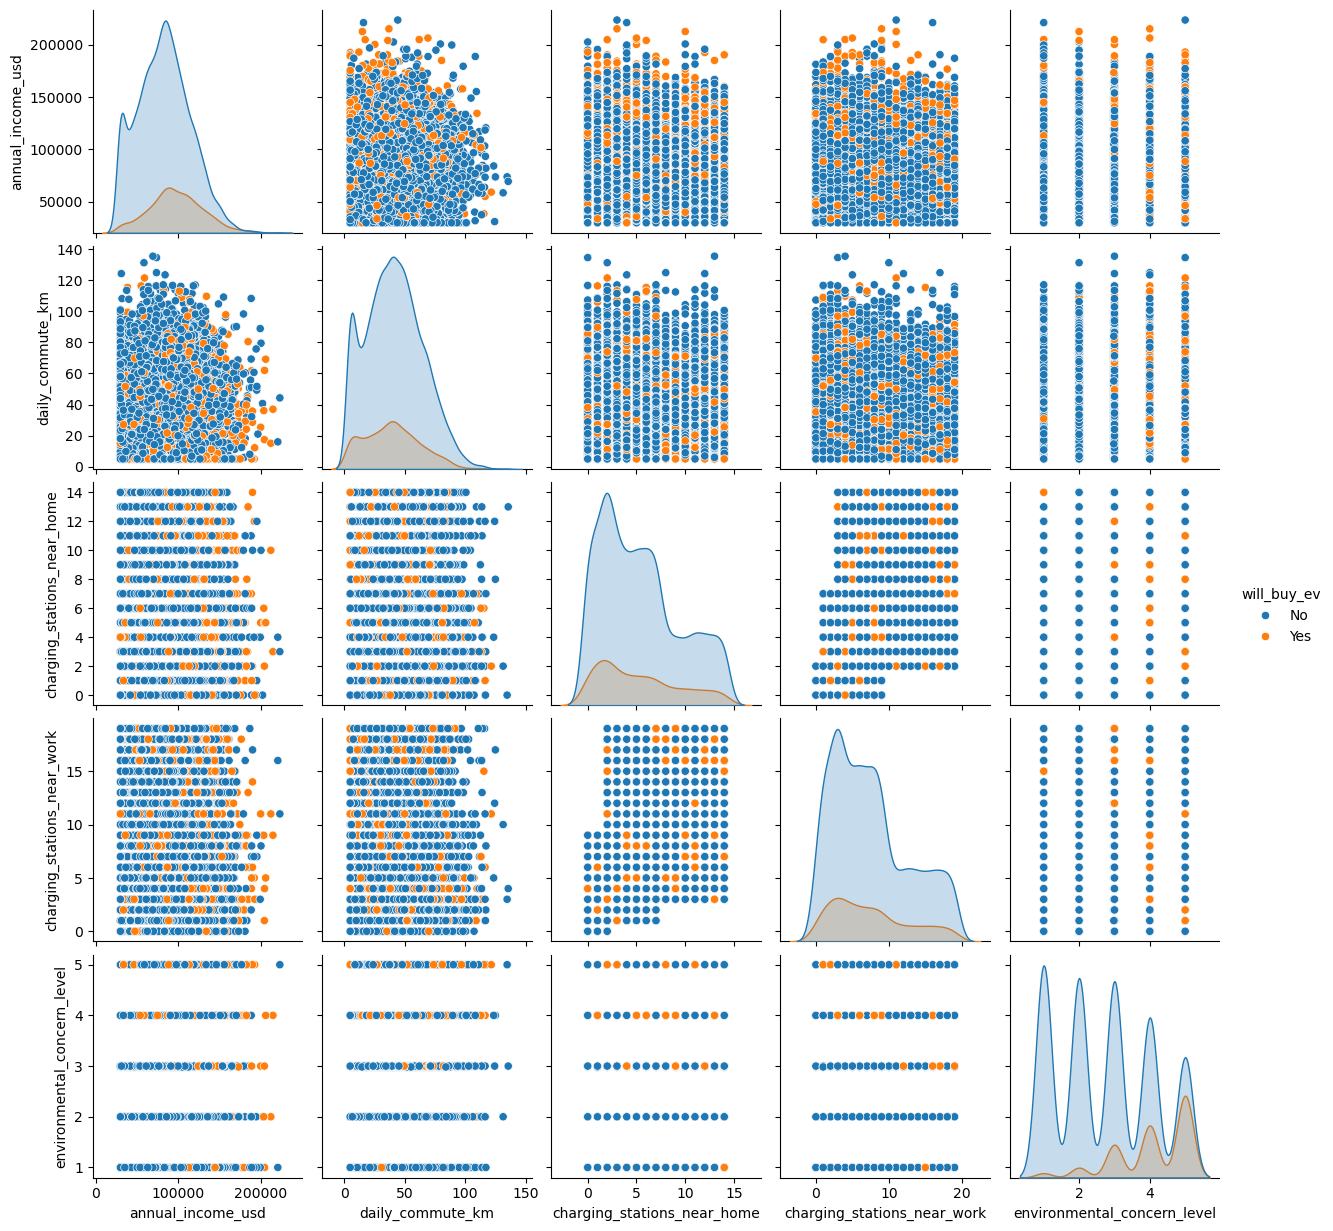

In [146]:
# Discussing how numerical datas are related to each other
sns.pairplot(
    df[[
        "annual_income_usd",
        "daily_commute_km",
        "charging_stations_near_home",
        "charging_stations_near_work",
        "environmental_concern_level",
        "will_buy_ev"
        
    ]],
    
    hue="will_buy_ev"
)

plt.show()

*From graph its clear that neither  no of charging stations near home or working place creates a difference but,
enviorment concern level does*

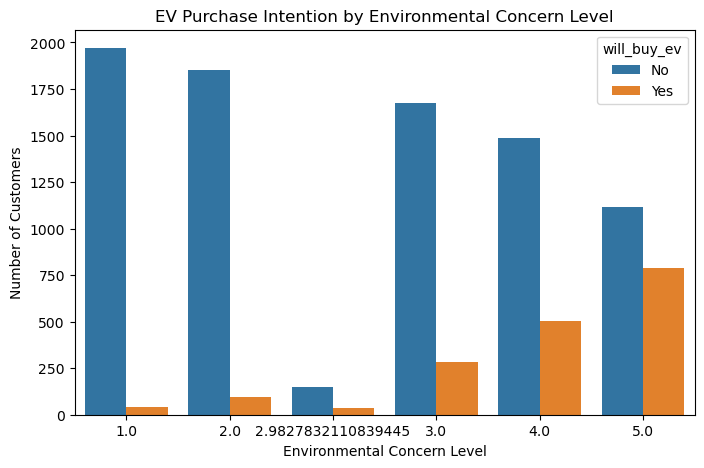

In [147]:
#checking wheather the enviornment corcern is actively pushing people to ev vehicles 
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="environmental_concern_level",
    hue="will_buy_ev"
)

plt.title("EV Purchase Intention by Environmental Concern Level")
plt.xlabel("Environmental Concern Level")
plt.ylabel("Number of Customers")

plt.show()

*Its clear that people who are highly conscious about pollution are more in to ev*

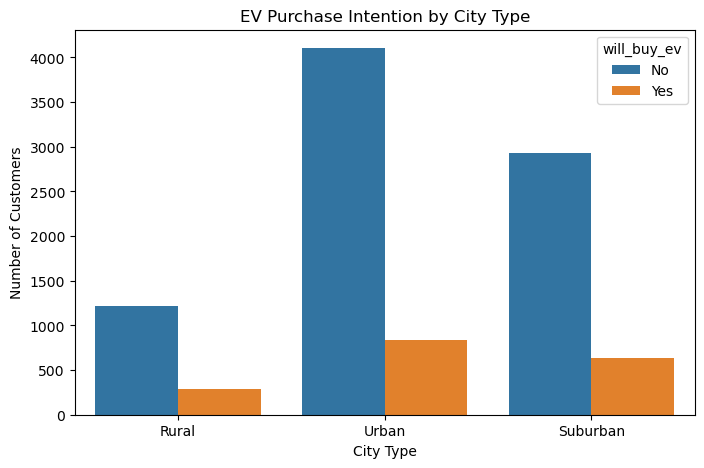

In [148]:
#Does city type creates a diffrence in opting ev
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="city_type",
    hue="will_buy_ev"
)

plt.title("EV Purchase Intention by City Type")
plt.xlabel("City Type")
plt.ylabel("Number of Customers")

plt.show()

*The  graph is saying that percenatge wise people living in rural areas shows more intrest in buying ev*

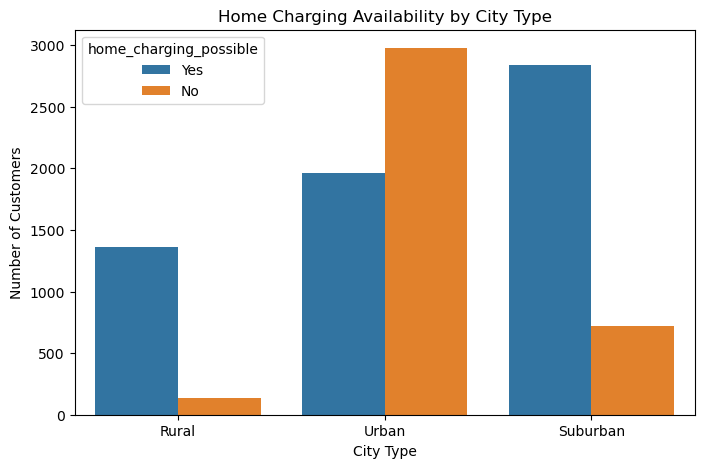

In [149]:
#Home charging availabilty in each city type
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="city_type",
    hue="home_charging_possible"
)

plt.title("Home Charging Availability by City Type")
plt.xlabel("City Type")
plt.ylabel("Number of Customers")

plt.show()

*From graph its cleat that people living on rural areas has more home charging availabilty,
thats why customers from rural areas is showing more intrest*

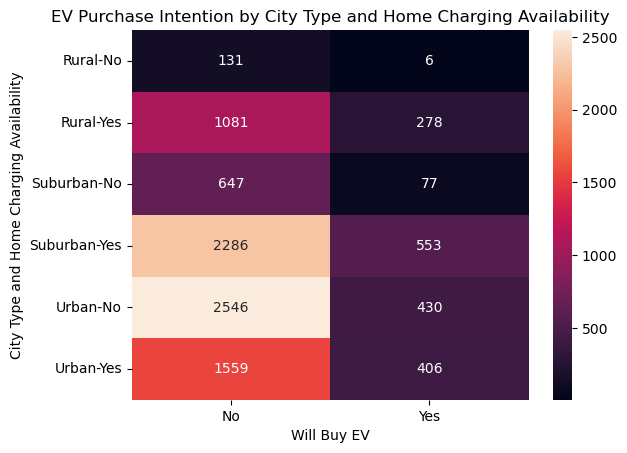

In [150]:
# checking how much influence on ev buying intention by home charging facility in each city type
table = pd.crosstab(
    [df["city_type"], df["home_charging_possible"]],
    df["will_buy_ev"]
)

sns.heatmap(
    table,
    annot=True,
    fmt="d"
)

plt.title("EV Purchase Intention by City Type and Home Charging Availability")
plt.xlabel("Will Buy EV")
plt.ylabel("City Type and Home Charging Availability")

plt.show()

In [151]:
df.head()

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,will_buy_ev_score
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No,5
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No,5
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes,3
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No,4
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No,5


## Key Insights

1. **Range anxiety:** Customers with higher range anxiety show lower interest in buying EVs.

2. **Subsidy availability:** Customers with subsidies available show greater EV purchase intention.

3. **Environmental concern:** Customers with higher environmental concern are more likely to show interest in EVs.

4. **Home charging:** Rural customers have the highest home-charging availability, while urban customers have much lower availability.

5. **City type:** EV buying interest differs across city types, with rural customers showing a relatively higher purchase intention percentage.

6. **Annual Income:** people having an average annual income close to 100k dollalrs prefer to buy EV cars more.

## Business Recommendation
1. Fear of Range anxiety is a big issue among customers ,it can be solved by providing batteries offrering more range
   and also creating an awareness about the diecent amount of range which are currently offering bu EV cars.
   
2. Marketing vehicles more on states providing subsidary can elevate the sales.

3. By creating constant awareness about Enviornmental problems from traditional vehicles in marketing ads can make people
   more Enviornment conscious and there by increase the sales.

4. EV buying intrest is more in Rural areas so company should actively focus on that city type.

5. Customers with an annual income above $100K show comparatively lower interest in buying EVs. EV manufacturers could focus on offering more       premium   features, quality, and luxury options to attract this higher-income customer segment.